In [15]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
from scipy import constants
import math
import h5py
import platophot as phot

In [16]:
sim = Simulation("JitterSmoothing")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]
workDir = os.environ["PLATO_WORKDIR"]

sim["ObservingParameters/NumExposures"] = 1
dim = 9
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

# One full-frame exposure

sim["CCD/IncludeConvolution"] = "no"
sim["PSF/Model"] = "MappedGaussian"

ccdCode = '2'
sim["CCD/Position"] = ccdCode

pixelSize = sim["CCD/PixelSize"] * constants.micro / constants.milli

ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, (dim) / 2, (dim) / 2)

ra = math.degrees(ra)
dec = math.degrees(dec)

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

myFile = open(starCatalogFilename, "w")
myFile.write("# RA DEC Vmag starID\n")
myFile.write("{0}  {1}  {2}  {3}\n".format(ra, dec, 12.5, 1))
myFile.close()

sim["ControlHDF5Content/WriteSubPixelImages"] = True

In [17]:
sim["CCD/IncludeConvolution"] = "yes"
sim["PSF/Model"] = "MappedGaussian"

In [18]:
numSubPixels = sim["SubField/SubPixels"]

# Size of the source

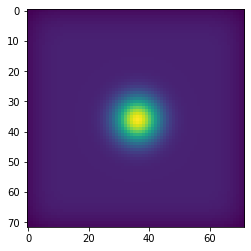

In [19]:
imageWithoutJS = sim.run(removeOutputFile = True).getSubPixelImage(0)
plt.imshow(imageWithoutJS)

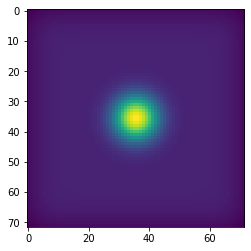

In [20]:
sim["PSF/MappedGaussian/IncludeJitterSmoothing"] = "yes"
imageWithJS = sim.run(removeOutputFile = True).getSubPixelImage(0)
plt.imshow(imageWithJS)

In [21]:
dim = dim * sim["SubField/SubPixels"]
sigma = sim["PSF/MappedGaussian/Sigma"] * numSubPixels
params = fitGaussian2D(imageWithoutJS, np.max(imageWithoutJS), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
print("Sigma:", params[3] / numSubPixels)
print("vs.", sigma / numSubPixels)

Sigma: 0.6427174390895091
vs. 0.639


In [25]:
sigma = math.sqrt(math.pow(sim["PSF/MappedGaussian/Sigma"], 2) + math.pow(0.5 / sim["SubField/SubPixels"], 2)) * numSubPixels
params = fitGaussian2D(imageWithoutJS, np.max(imageWithoutJS), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
print("Sigma:", params[3] / numSubPixels)
print("vs.", sigma / numSubPixels)

Sigma: 0.6427173965760238
vs. 0.6420492582349114


# Photometry

In [27]:
dim = 21

sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, (dim) / 2, (dim) / 2)

ra = math.degrees(ra)
dec = math.degrees(dec)

sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

myFile = open(starCatalogFilename, "w")
myFile.write("# RA DEC Vmag starID\n")
myFile.write("{0}  {1}  {2}  {3}\n".format(ra, dec, 12.5, 1))
myFile.close()

sim["ControlHDF5Content/WriteSubPixelImages"] = False

numExposures = 5000
sim["ObservingParameters/NumExposures"] = numExposures

sim["Platform/UseJitter"] = True
sim["Platform/JitterSource"] = "FromFile"
sim["Platform/JitterPitchRms"] = 0
sim["Platform/JitterRollRms"] = 0

sim["PSF/MappedGaussian/IncludeJitterSmoothing"] = "no"

output = sim.run(removeOutputFile = True)

In [28]:
outputFile = h5py.File(workDir + "JitterSmoothing.hdf5")
starIDsInImage0, row, col, Xmm, Ymm, flux = output.getStarCoordinates(0)

print("Start")
phot.photometry(workDir + "JitterSmoothing.hdf5", "photometryOutputWithoutJS.hdf5", starIDsInImage0, maxNexposures=numExposures)
print("Done")

Start
0 5000
Looping over all images in HDF5 file.
Image # 0
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.02502502

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

...

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Done


In [29]:
photFile = h5py.File("photometryOutputWithoutJS.hdf5")

In [30]:
fluxesWithoutJS = np.array([])

for exposure in range(numExposures):
    
    name = "/Photometry/Exposure{:06d}/estimatedFlux".format(exposure)
    flux = np.array(photFile[name])
    fluxesWithoutJS = np.append(fluxesWithoutJS, flux)

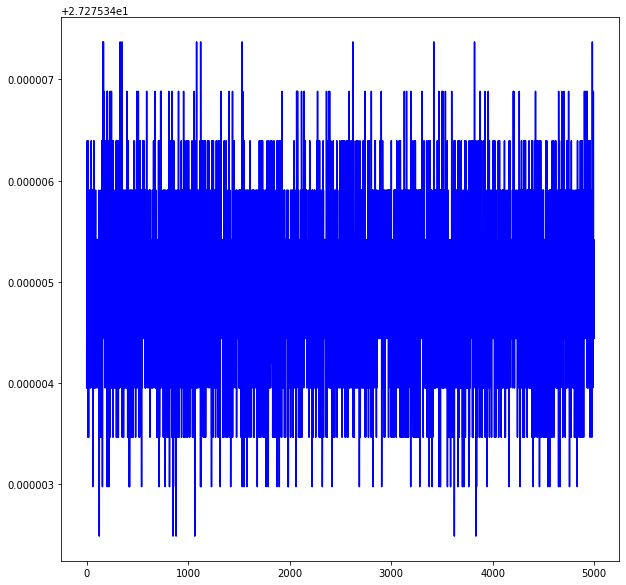

In [31]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)

plt.plot(fluxesWithoutJS * 1e-5, "b")

In [32]:
sim["PSF/MappedGaussian/IncludeJitterSmoothing"] = "yes"

outputWithJS = sim.run(removeOutputFile = True)

outputFile = h5py.File(workDir + "JitterSmoothing.hdf5")
starIDsInImage0, row, col, Xmm, Ymm, flux = output.getStarCoordinates(0)

In [33]:
print("Start")
phot.photometry(workDir + "JitterSmoothing.hdf5", "photometryOutputWithJS.hdf5", starIDsInImage0, maxNexposures=numExposures)
print("Done")

Start
0 5000
Looping over all images in HDF5 file.
Image # 0
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.02502502

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

...

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Subtracted bias level of 0.0 ADU
    Corre

In [34]:
photFile = h5py.File("photometryOutputWithJS.hdf5")

In [35]:
fluxesWithJS = np.array([])

for exposure in range(numExposures):
    
    name = "/Photometry/Exposure{:06d}/estimatedFlux".format(exposure)
    flux = np.array(photFile[name])
    fluxesWithJS = np.append(fluxesWithJS, flux)

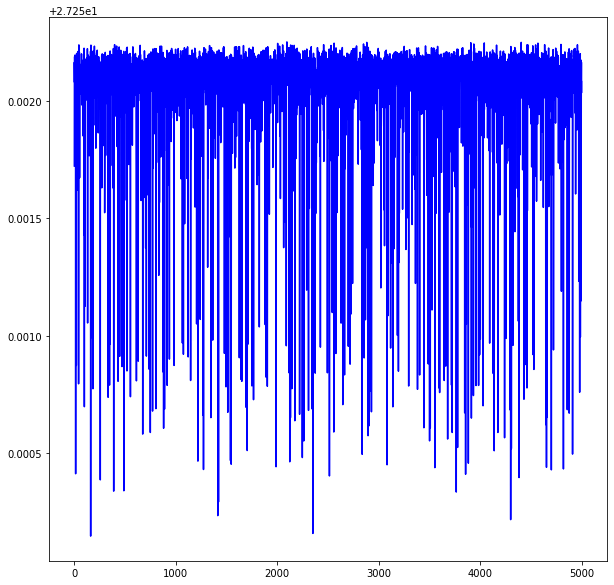

In [36]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)

plt.plot(fluxesWithJS * 1e-5, "b")

(0, 500)

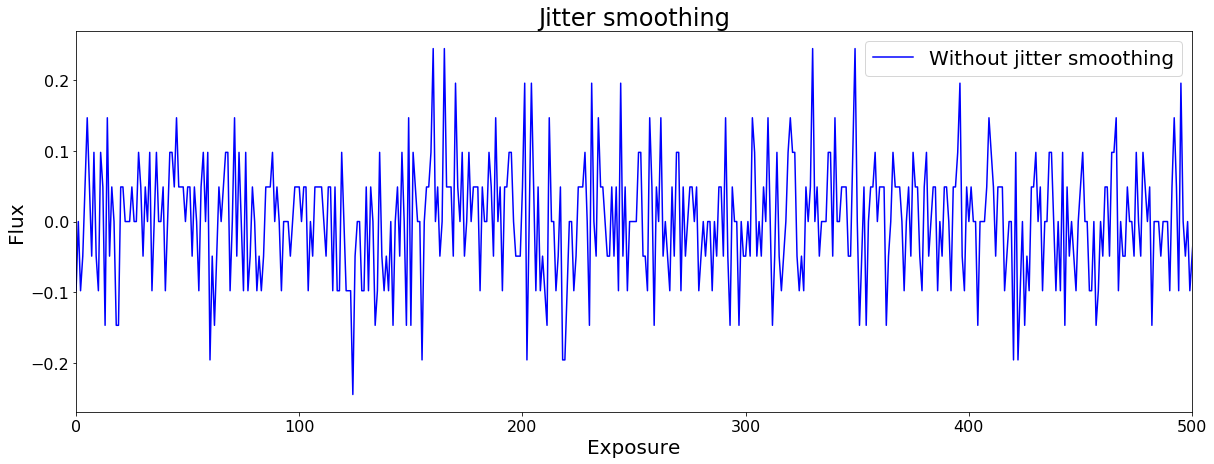

In [42]:
fig = plt.figure(figsize = (20, 7))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(fluxesWithoutJS - np.median(fluxesWithoutJS), "b", label="Without jitter smoothing")
# plt.plot(fluxesWithoutJS - fluxesWithoutJS[0], "b", label="Without jitter smoothing")
# plt.plot(fluxesWithJS, "r", label="With jitter smoothing")



########
# Layout
########

plt.title("Jitter smoothing", fontsize = 24)
plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Flux", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0,500])

(0, 500)

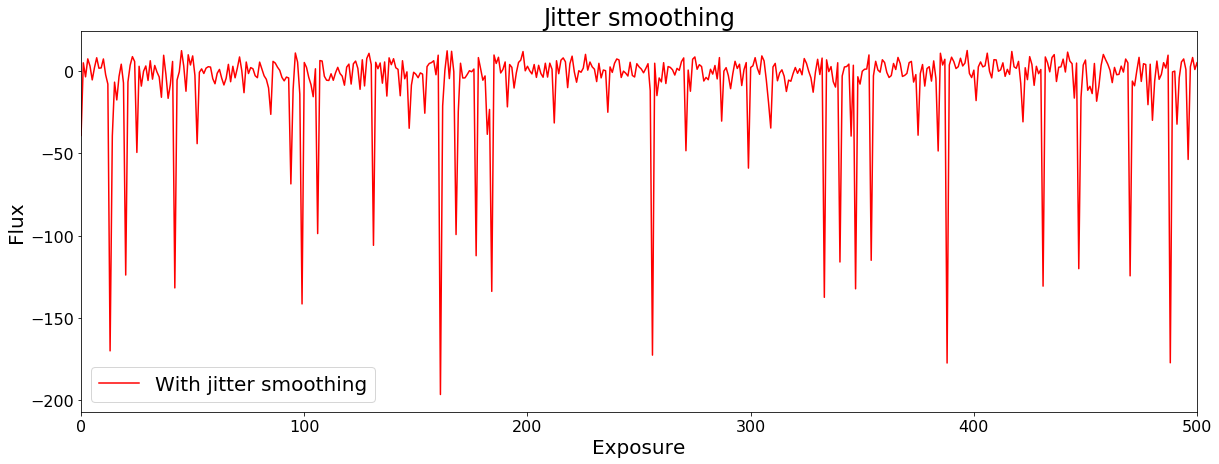

In [43]:
fig = plt.figure(figsize = (20, 7))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(fluxesWithJS - np.median(fluxesWithJS), "r", label="With jitter smoothing")
# plt.plot(fluxesWithJS - fluxesWithJS[0], "r", label="With jitter smoothing")



########
# Layout
########

plt.title("Jitter smoothing", fontsize = 24)
plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Flux", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0,500])

(0, 500)

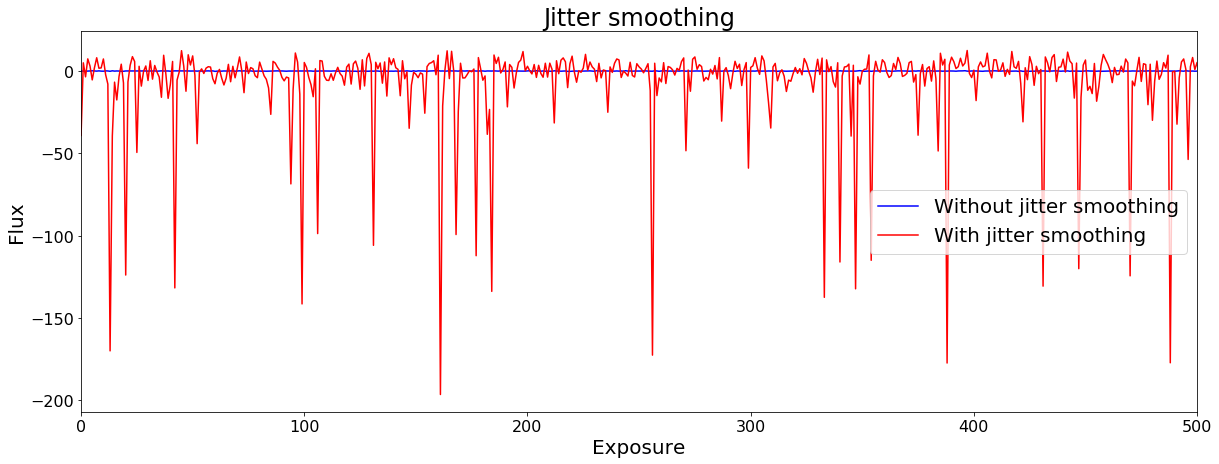

In [44]:
fig = plt.figure(figsize = (20, 7))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(fluxesWithoutJS - np.median(fluxesWithoutJS), "b", label="Without jitter smoothing")
plt.plot(fluxesWithJS - np.median(fluxesWithJS), "r", label="With jitter smoothing")



########
# Layout
########

plt.title("Jitter smoothing", fontsize = 24)
plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Flux", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0,500])